In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from heston.closed import heston_call_price
from black_scholes.bs import black_scholes

from neural_network.config import ModelConfig, HestonParams
from neural_network.trainer import HestonTrainer

## Neural network vs Closed form

In [2]:
S0 = 1.0   # Initial stock price
K = 1.0    # Strike price
T = 1.0      # Time to maturity
r = 0.05     # Risk-free rate
kappa = 2.0  # Mean reversion rate
theta = 0.04 # Long-term variance
sigma = 0.3  # Volatility of variance
rho = -0.7   # Correlation
v0 = 0.04    # Initial variance

S_max = 3 * S0
V_max = 0.5

params = HestonParams(
    S0=S0, v0=v0, r=r, kappa=kappa, theta=theta, sigma=sigma, rho=rho, T=T, K=K,
    S_max=S_max, V_max=V_max
)

model_config = ModelConfig(
    input_size=3,
    hidden_sizes=[64, 128, 128, 64],
    output_size=1,
    activation=nn.ReLU(),
    learning_rate=1e-4
)

loss_weights = {
    'pde': 5000.0,
    'payoff': 0.5,
    'S_min': 10.0,
    'S_max': 0.1,
    'V_min': 1000.0,
    'V_max': 0.01
}

heston_trainer = HestonTrainer(model_config=model_config, heston_params=params, payoff=None, loss_weights=loss_weights, seed=42)

Iteration 0, Loss: 0.9254516363143921
Iteration 100, Loss: 0.3795245289802551
Iteration 200, Loss: 0.2688465416431427
Iteration 300, Loss: 0.17429664731025696
Iteration 400, Loss: 0.12763193249702454
Iteration 500, Loss: 0.10740169137716293
Iteration 600, Loss: 0.09698157012462616
Iteration 700, Loss: 0.08939811587333679
Iteration 800, Loss: 0.07808537781238556
Iteration 900, Loss: 0.06219428405165672
Iteration 1000, Loss: 0.053439605981111526
Iteration 1100, Loss: 0.04719863831996918
Iteration 1200, Loss: 0.040971919894218445
Iteration 1300, Loss: 0.03463686257600784
Iteration 1400, Loss: 0.031212197616696358
Iteration 1500, Loss: 0.027329949662089348
Iteration 1600, Loss: 0.027127064764499664
Iteration 1700, Loss: 0.02402651682496071
Iteration 1800, Loss: 0.02233363687992096
Iteration 1900, Loss: 0.020585928112268448
Iteration 2000, Loss: 0.019799239933490753
Iteration 2100, Loss: 0.019184263423085213
Iteration 2200, Loss: 0.019056927412748337
Iteration 2300, Loss: 0.0178632028400897

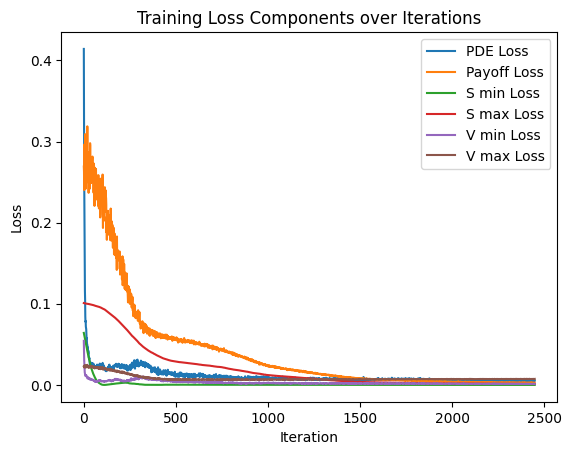

In [3]:
heston_trainer.train(batch_size=1024, epochs=10000, tol=1e-6)
heston_trainer.plot_losses_detailed()

In [4]:
# grid resolution
num_S = 80
num_V = 80

Ss = np.linspace(0.01, S_max, num_S)
Vs = np.linspace(0, V_max, num_V)
t = 0

nn_prices = np.zeros((num_V, num_S))
cf_prices = np.zeros((num_V, num_S))

for i, v_val in enumerate(Vs):
    for j, s_val in enumerate(Ss):
        nn_prices[i, j] = heston_trainer.predict(t, s_val, v_val).item()
        cf_prices[i, j] = heston_call_price(s_val, K, T - t, r, kappa, theta, sigma, rho, v_val)

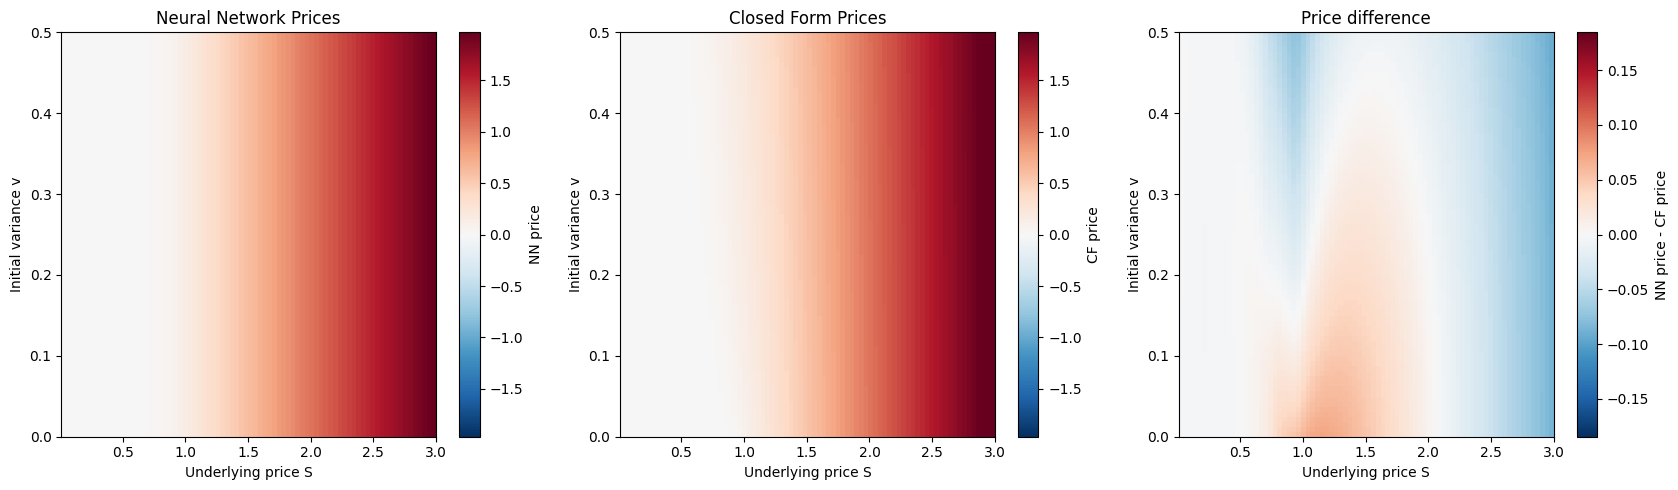

In [5]:
plt.figure(figsize=(17, 5))

plt.subplot(1, 3, 1)
vmax = np.abs(nn_prices).max()
vmin = -vmax
im = plt.imshow(nn_prices, extent=[Ss[0], Ss[-1], Vs[0], Vs[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(im, label='NN price')
plt.xlabel('Underlying price S')
plt.ylabel('Initial variance v')
plt.title('Neural Network Prices')

plt.subplot(1, 3, 2)
im2 = plt.imshow(cf_prices, extent=[Ss[0], Ss[-1], Vs[0], Vs[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(im2, label='CF price')
plt.xlabel('Underlying price S')
plt.ylabel('Initial variance v')
plt.title('Closed Form Prices')

plt.subplot(1, 3, 3)
diff = nn_prices - cf_prices
vmax = np.abs(diff).max()*2
vmin = -vmax
im3 = plt.imshow(diff, extent=[Ss[0], Ss[-1], Vs[0], Vs[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(im3, label='NN price - CF price')
plt.xlabel('Underlying price S')
plt.ylabel('Initial variance v')
plt.title('Price difference')
plt.tight_layout()
plt.show()

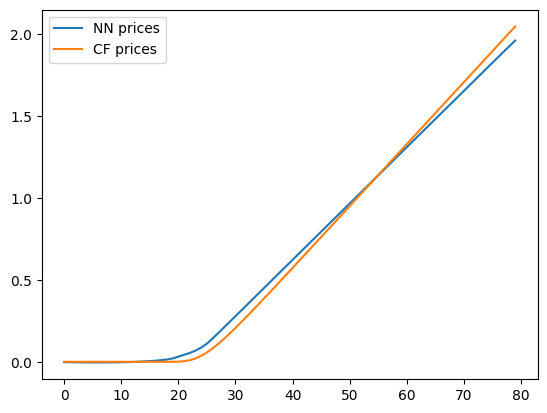

In [6]:
v_ind = 0
plt.plot(nn_prices[v_ind, :], label='NN prices')
plt.plot(cf_prices[v_ind, :], label='CF prices')
plt.legend()
plt.show()